In [1]:
# ============================================================
# 1. SETUP
# ============================================================
!pip install -q pandas numpy matplotlib seaborn plotly missingno

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

sns.set_theme(style='whitegrid', rc={'figure.figsize': (12, 6)})
pd.set_option('display.max_columns', None)

In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================
from google.colab import files
uploaded = files.upload()  # select train.csv when prompted

df = pd.read_csv('train.csv')
print(df.shape)
df.head()

Saving train.csv to train.csv
(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

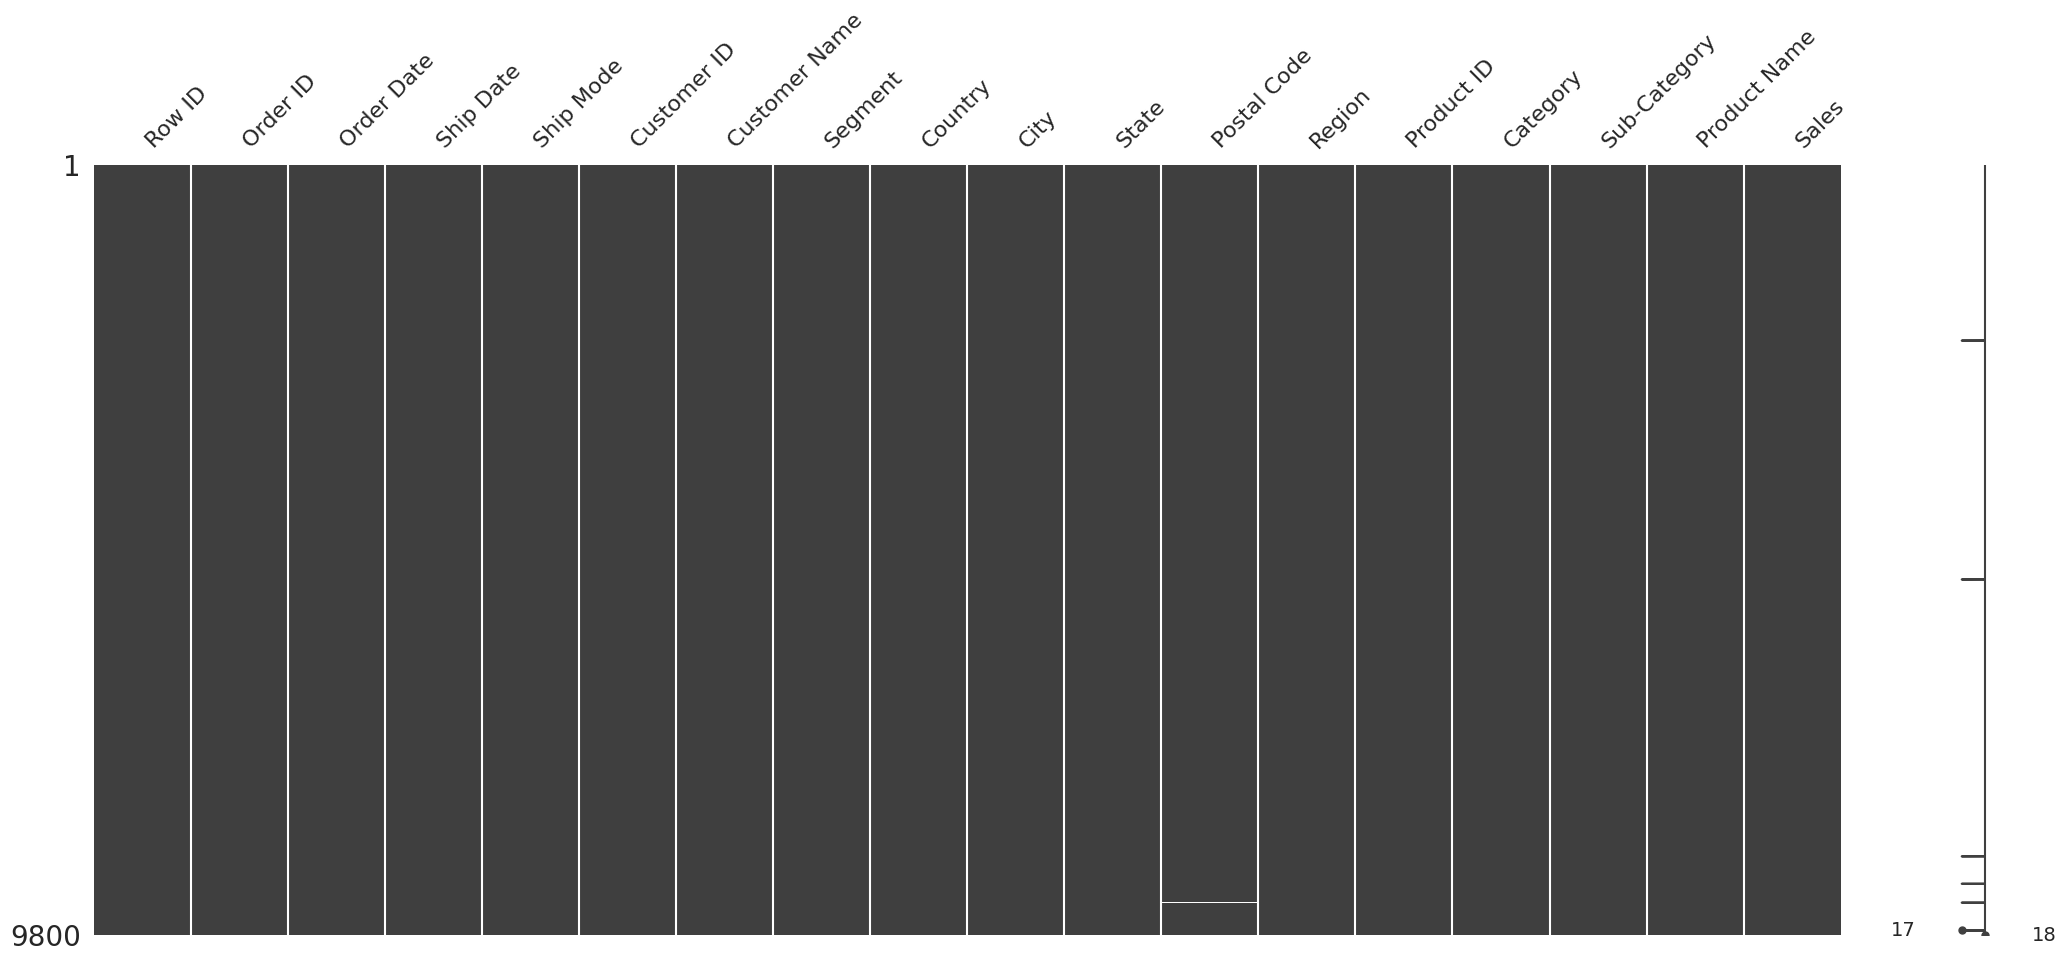

Duplicate rows: 0


In [3]:
# ============================================================
# 3. FIRST LOOK
# ============================================================
df.info()
df.describe(include='number').T
df.describe(include='object').T

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
if len(missing) > 0:
    msno.matrix(df)
    plt.show()

print('Duplicate rows:', df.duplicated().sum())

In [4]:
# ============================================================
# 4. CLEANING
# ============================================================
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.to_period('M').astype(str)
df['Order Weekday'] = df['Order Date'].dt.day_name()
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

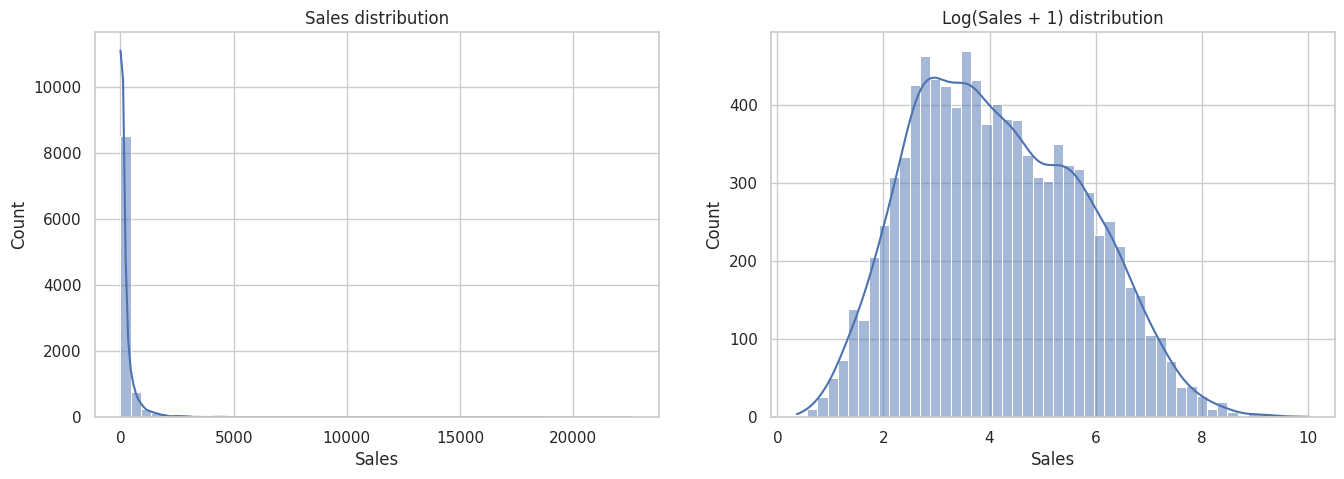

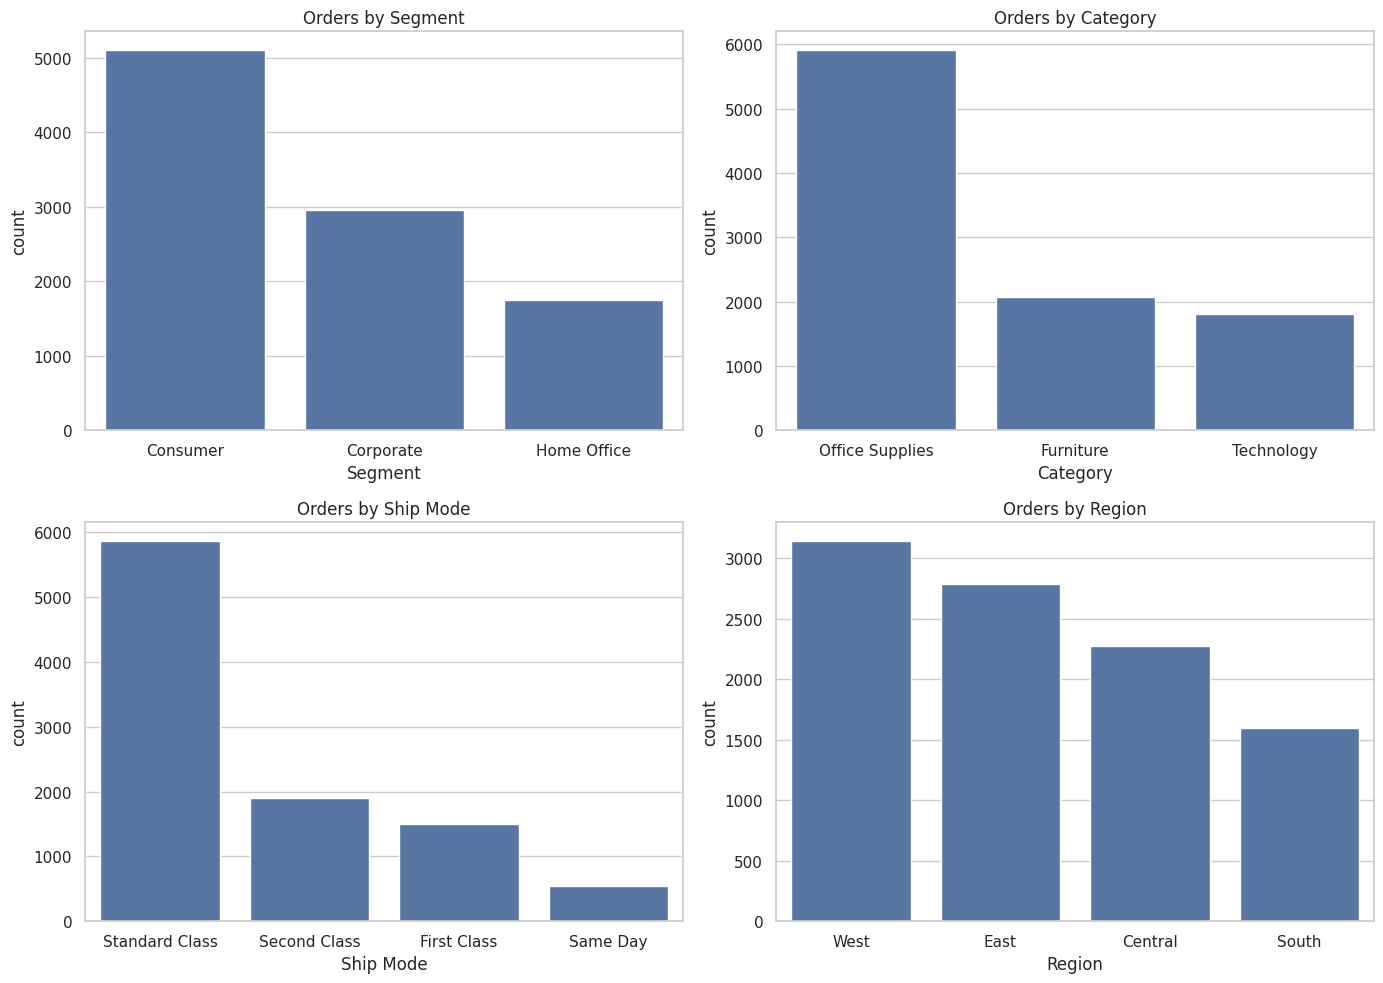

In [5]:
# ============================================================
# 5. UNIVARIATE ANALYSIS — DISTRIBUTIONS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Sales distribution')

sns.histplot(np.log1p(df['Sales']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log(Sales + 1) distribution')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x='Segment', order=df['Segment'].value_counts().index, ax=axes[0,0])
axes[0,0].set_title('Orders by Segment')

sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, ax=axes[0,1])
axes[0,1].set_title('Orders by Category')

sns.countplot(data=df, x='Ship Mode', order=df['Ship Mode'].value_counts().index, ax=axes[1,0])
axes[1,0].set_title('Orders by Ship Mode')

sns.countplot(data=df, x='Region', order=df['Region'].value_counts().index, ax=axes[1,1])
axes[1,1].set_title('Orders by Region')

plt.tight_layout()
plt.show()

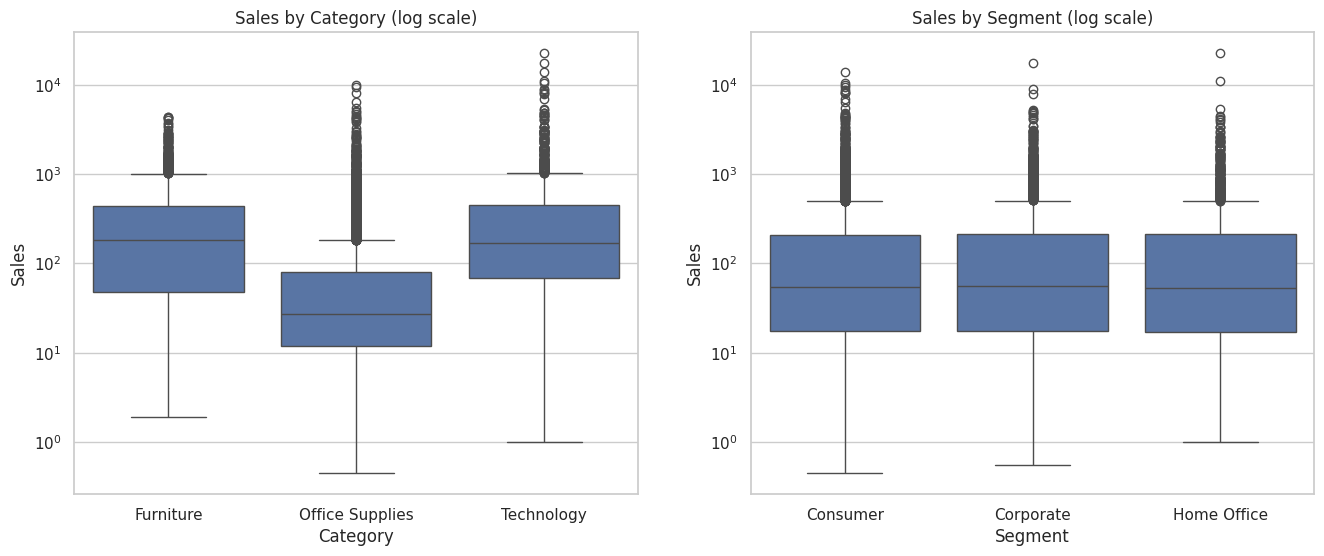

/tmp/ipykernel_1668/1059697047.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_subcats, x='Sales', y='Sub-Category', palette='viridis')


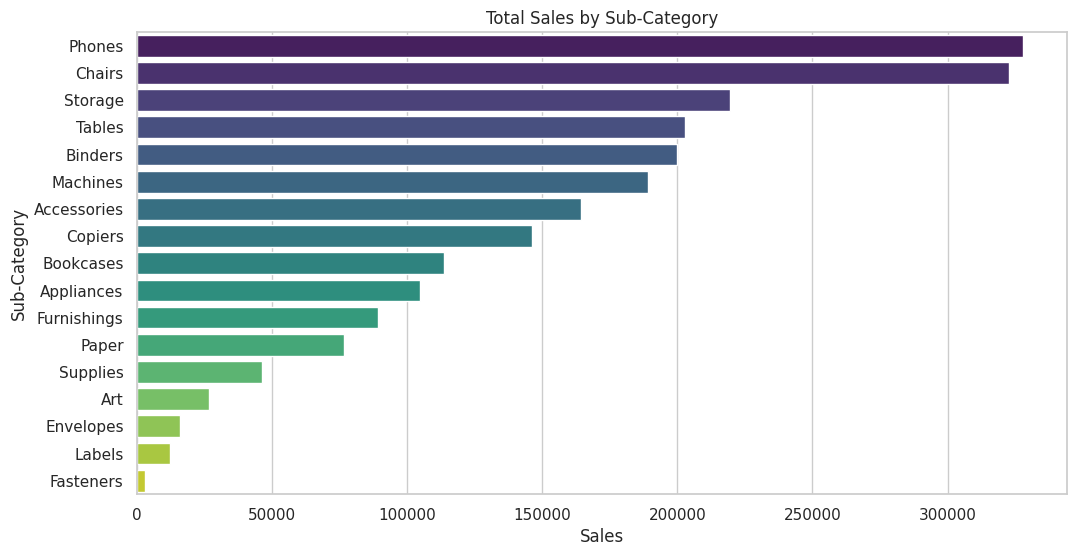

/tmp/ipykernel_1668/1059697047.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_states, x='Sales', y='State', palette='mako')


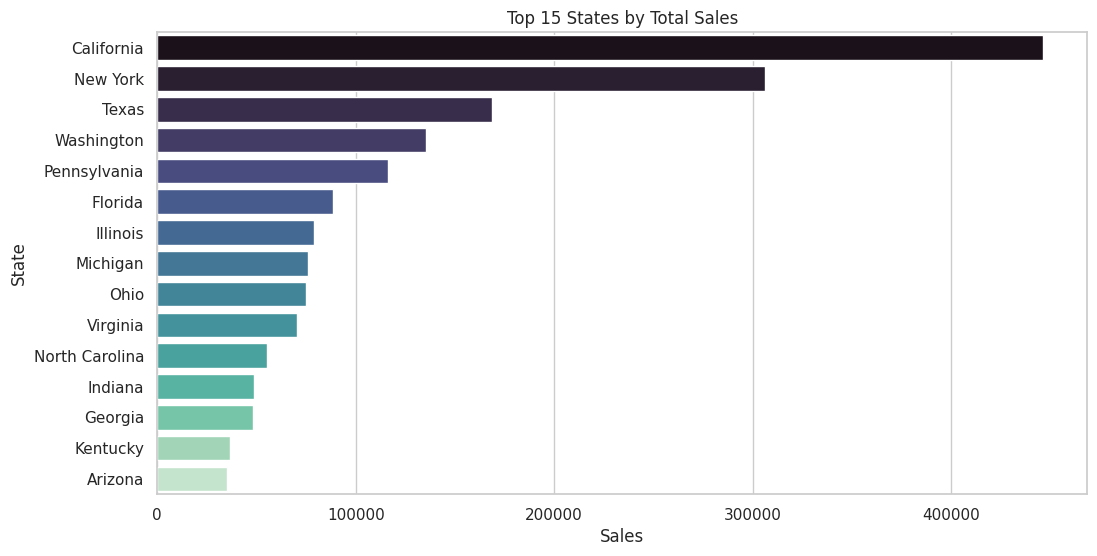

In [6]:
# ============================================================
# 6. BIVARIATE ANALYSIS — SALES VS. CATEGORICAL FEATURES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='Category', y='Sales', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Sales by Category (log scale)')

sns.boxplot(data=df, x='Segment', y='Sales', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Sales by Segment (log scale)')
plt.show()

top_subcats = df.groupby('Sub-Category', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
ax = sns.barplot(data=top_subcats, x='Sales', y='Sub-Category', palette='viridis')
ax.set_title('Total Sales by Sub-Category')
plt.show()

top_states = df.groupby('State', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False).head(15)
ax = sns.barplot(data=top_states, x='Sales', y='State', palette='mako')
ax.set_title('Top 15 States by Total Sales')
plt.show()


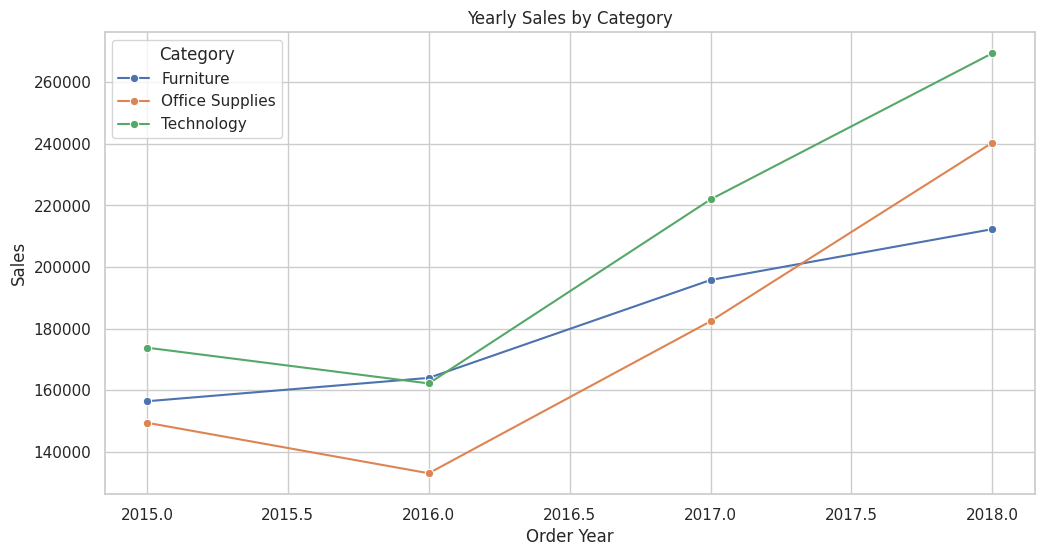

/tmp/ipykernel_1668/3853618184.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




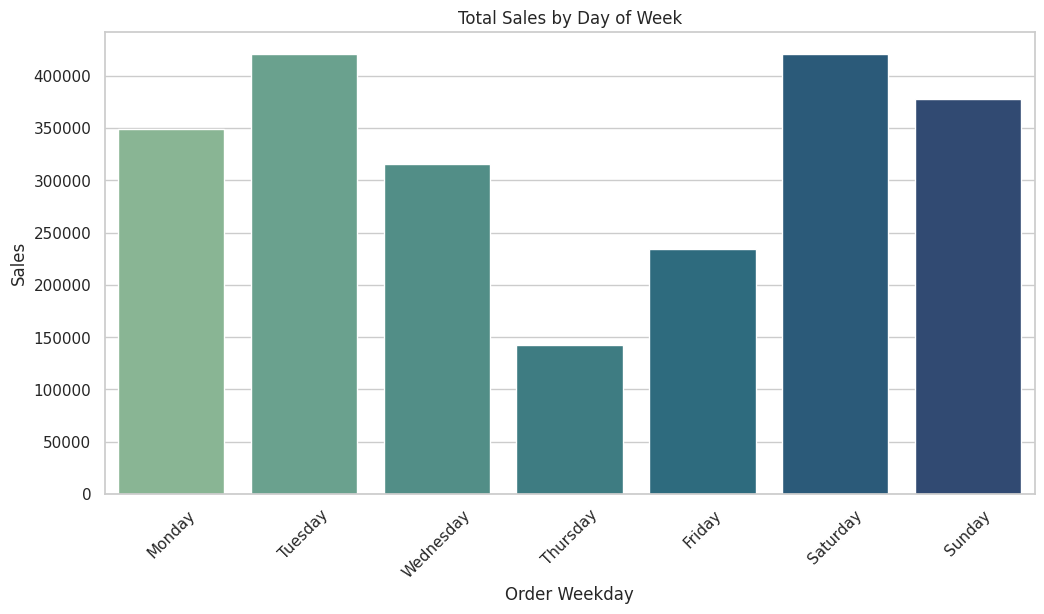

In [7]:
# ============================================================
# 7. TIME TRENDS
# ============================================================
monthly_sales = df.groupby('Order Month', as_index=False)['Sales'].sum()
fig = px.line(monthly_sales, x='Order Month', y='Sales', title='Monthly Sales Trend')
fig.update_xaxes(tickangle=45)
fig.show()

yearly_cat_sales = df.groupby(['Order Year', 'Category'], as_index=False)['Sales'].sum()
ax = sns.lineplot(data=yearly_cat_sales, x='Order Year', y='Sales', hue='Category', marker='o')
ax.set_title('Yearly Sales by Category')
plt.show()

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = df.groupby('Order Weekday', as_index=False)['Sales'].sum()
weekday_sales['Order Weekday'] = pd.Categorical(weekday_sales['Order Weekday'], categories=weekday_order, ordered=True)
weekday_sales = weekday_sales.sort_values('Order Weekday')
ax = sns.barplot(data=weekday_sales, x='Order Weekday', y='Sales', palette='crest')
ax.set_title('Total Sales by Day of Week')
plt.xticks(rotation=45)
plt.show()

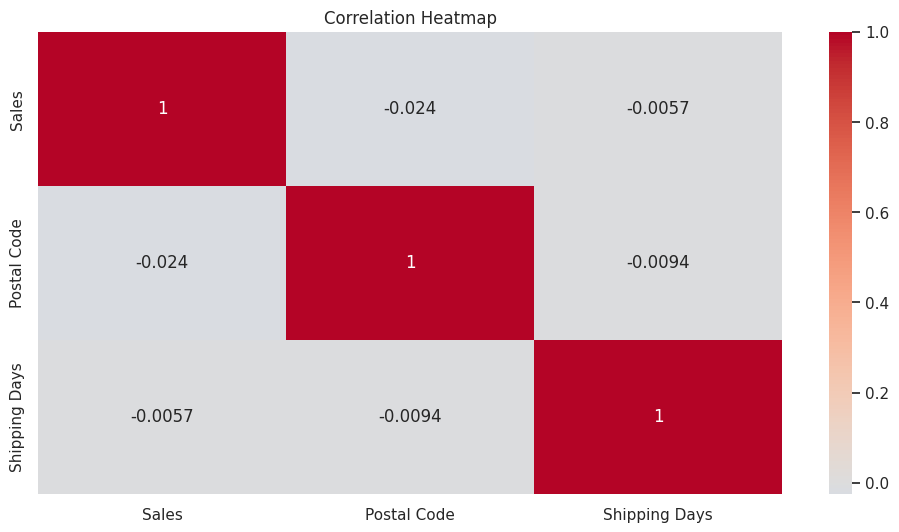

In [8]:
# ============================================================
# 8. CORRELATIONS
# ============================================================
numeric_cols = ['Sales', 'Postal Code', 'Shipping Days']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

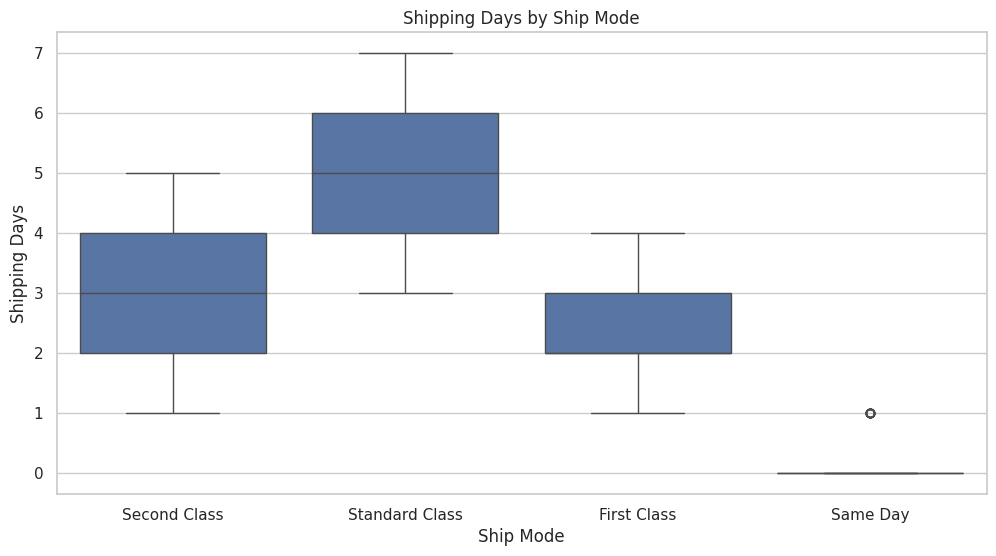

In [9]:
# ============================================================
# 9. SHIPPING PERFORMANCE
# ============================================================
ax = sns.boxplot(data=df, x='Ship Mode', y='Shipping Days')
ax.set_title('Shipping Days by Ship Mode')
plt.show()